In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

In [2]:

np.random.seed(42)

In [3]:

# y lambda_t = efecto_anual + efecto_mensual + efecto_diario.

efecto_anual = {2023: 1000, 2024: 1500, 2025: 2000}


efecto_mensual = {
    1: 1000,   # Enero
    2: 1500,   # Febrero
    3: 2000,   # Marzo
    4: 2000,   # Abril
    5: 2500,   # Mayo
    6: 2500,   # Junio
    7: 3000,   # Julio
    8: 2500,   # Agosto
    9: 2500,   # Septiembre
    10: 2000,  # Octubre
    11: 1500,  # Noviembre
    12: 1000,  # Diciembre
}


efecto_diario = {
    6: 1000,  # Domingo
    0: 2000,  # Lunes
    1: 3000,  # Martes
    2: 3500,  # Miércoles
    3: 3000,  # Jueves
    4: 2000,  # Viernes
    5: 1000,  # Sábado
}

In [4]:

fechas = pd.date_range(start="2023-01-01", end="2025-12-31", freq="D")


lambdas = np.array([
    efecto_anual[f.year] + efecto_mensual[f.month] + efecto_diario[f.dayofweek]
    for f in fechas
])


ventas_francisco = np.random.poisson(lambdas)
ventas_miguel = np.random.poisson(lambdas)


df = pd.DataFrame({
    "fecha": fechas,
    "lambda_t": lambdas,
    "ventas_francisco": ventas_francisco,
    "ventas_miguel": ventas_miguel,
})
df["año"] = df["fecha"].dt.year


print(f"Total de días simulados: {len(df)}")
print(f"\nPrimeras filas:")
print(df.head(10).to_string(index=False))
print(f"\nEstadísticas por año (Don Francisco):")
print(df.groupby("año")["ventas_francisco"].describe().to_string())
print(f"\nEstadísticas por año (Don Miguel):")
print(df.groupby("año")["ventas_miguel"].describe().to_string())

Total de días simulados: 1096

Primeras filas:
     fecha  lambda_t  ventas_francisco  ventas_miguel  año
2023-01-01      3000              2980           3012 2023
2023-01-02      4000              4044           4068 2023
2023-01-03      5000              4919           5015 2023
2023-01-04      5500              5521           5430 2023
2023-01-05      5000              5077           5085 2023
2023-01-06      4000              3935           4074 2023
2023-01-07      3000              2968           2891 2023
2023-01-08      3000              2989           2992 2023
2023-01-09      4000              4020           4023 2023
2023-01-10      5000              4956           5039 2023

Estadísticas por año (Don Francisco):
      count         mean          std     min     25%     50%     75%     max
año                                                                          
2023  365.0  5206.172603  1112.453066  2882.0  4417.0  5388.0  6043.0  7553.0
2024  366.0  5718.521858  1109.


Don Francisco 2023 — k=10, h=467.1, n=365
           Intervalo     fᵢ      f̂ᵢ = fᵢ/(n·h)
--------------------------------------------------
[   2882,    3349)     19  0.00011144
[   3349,    3816)     16  0.00009385
[   3816,    4283)     45  0.00026394
[   4283,    4750)     49  0.00028740
[   4750,    5218)     53  0.00031087
[   5218,    5685)     59  0.00034606
[   5685,    6152)     44  0.00025808
[   6152,    6619)     47  0.00027567
[   6619,    7086)     23  0.00013490
[   7086,    7553)     10  0.00005865
Verificación área total: 1.0000  (debe ser ≈ 1.0)

Don Francisco 2024 — k=10, h=472.1, n=366
           Intervalo     fᵢ      f̂ᵢ = fᵢ/(n·h)
--------------------------------------------------
[   3336,    3808)     17  0.00009839
[   3808,    4280)     17  0.00009839
[   4280,    4752)     44  0.00025465
[   4752,    5224)     53  0.00030673
[   5224,    5696)     52  0.00030095
[   5696,    6169)     61  0.00035303
[   6169,    6641)     39  0.00022571
[   6641,    7113)  

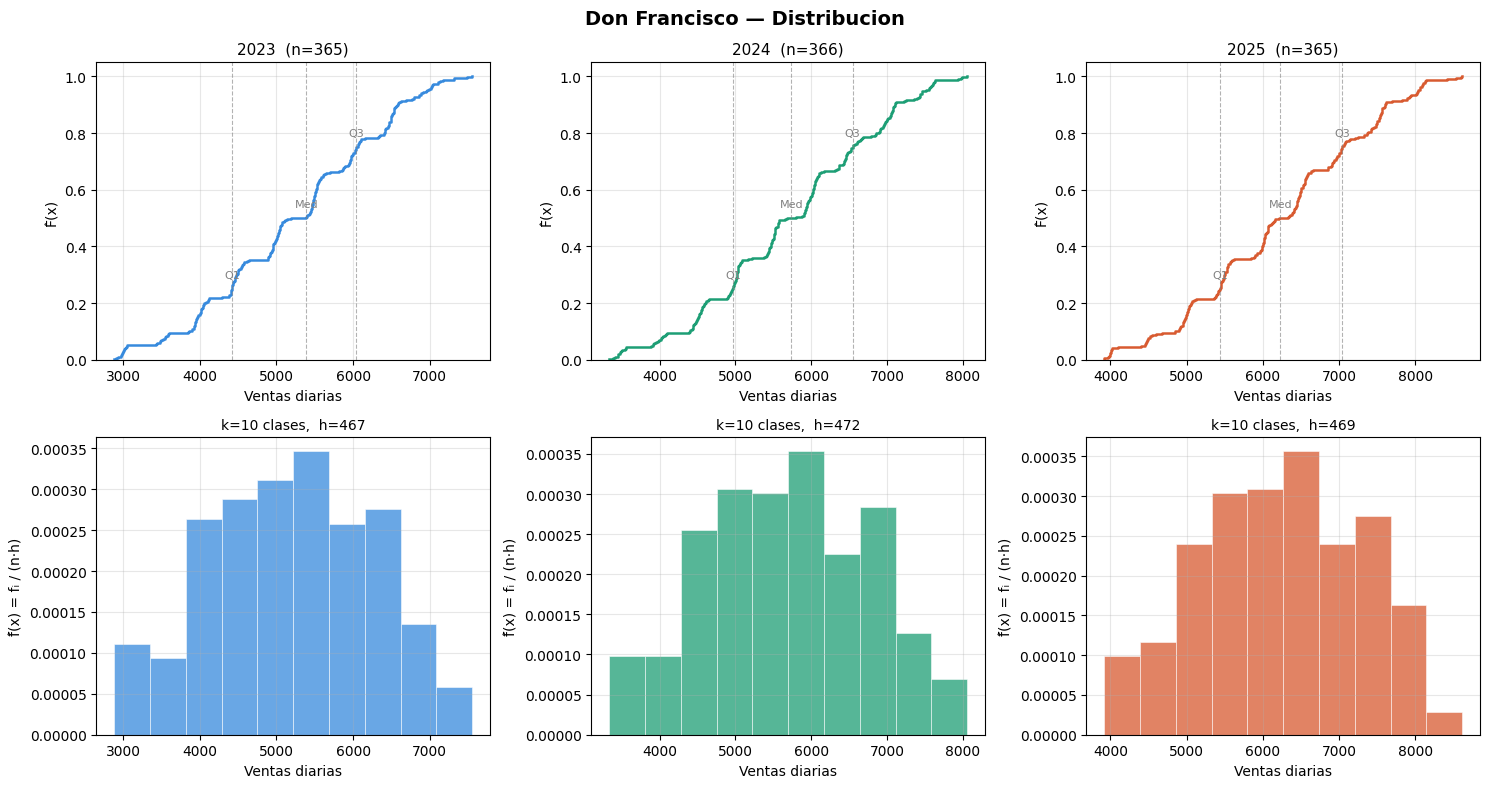


Don Miguel 2023 — k=10, h=477.4, n=365
           Intervalo     fᵢ      f̂ᵢ = fᵢ/(n·h)
--------------------------------------------------
[   2876,    3353)     19  0.00010904
[   3353,    3831)     16  0.00009182
[   3831,    4308)     45  0.00025825
[   4308,    4786)     49  0.00028120
[   4786,    5263)     53  0.00030416
[   5263,    5740)     60  0.00034433
[   5740,    6218)     44  0.00025251
[   6218,    6695)     49  0.00028120
[   6695,    7173)     23  0.00013199
[   7173,    7650)      7  0.00004017
Verificación área total: 1.0000  (debe ser ≈ 1.0)

Don Miguel 2024 — k=10, h=466.6, n=366
           Intervalo     fᵢ      f̂ᵢ = fᵢ/(n·h)
--------------------------------------------------
[   3427,    3894)     17  0.00009955
[   3894,    4360)     20  0.00011711
[   4360,    4827)     41  0.00024008
[   4827,    5293)     53  0.00031035
[   5293,    5760)     52  0.00030449
[   5760,    6227)     61  0.00035719
[   6227,    6693)     44  0.00025765
[   6693,    7160)     46 

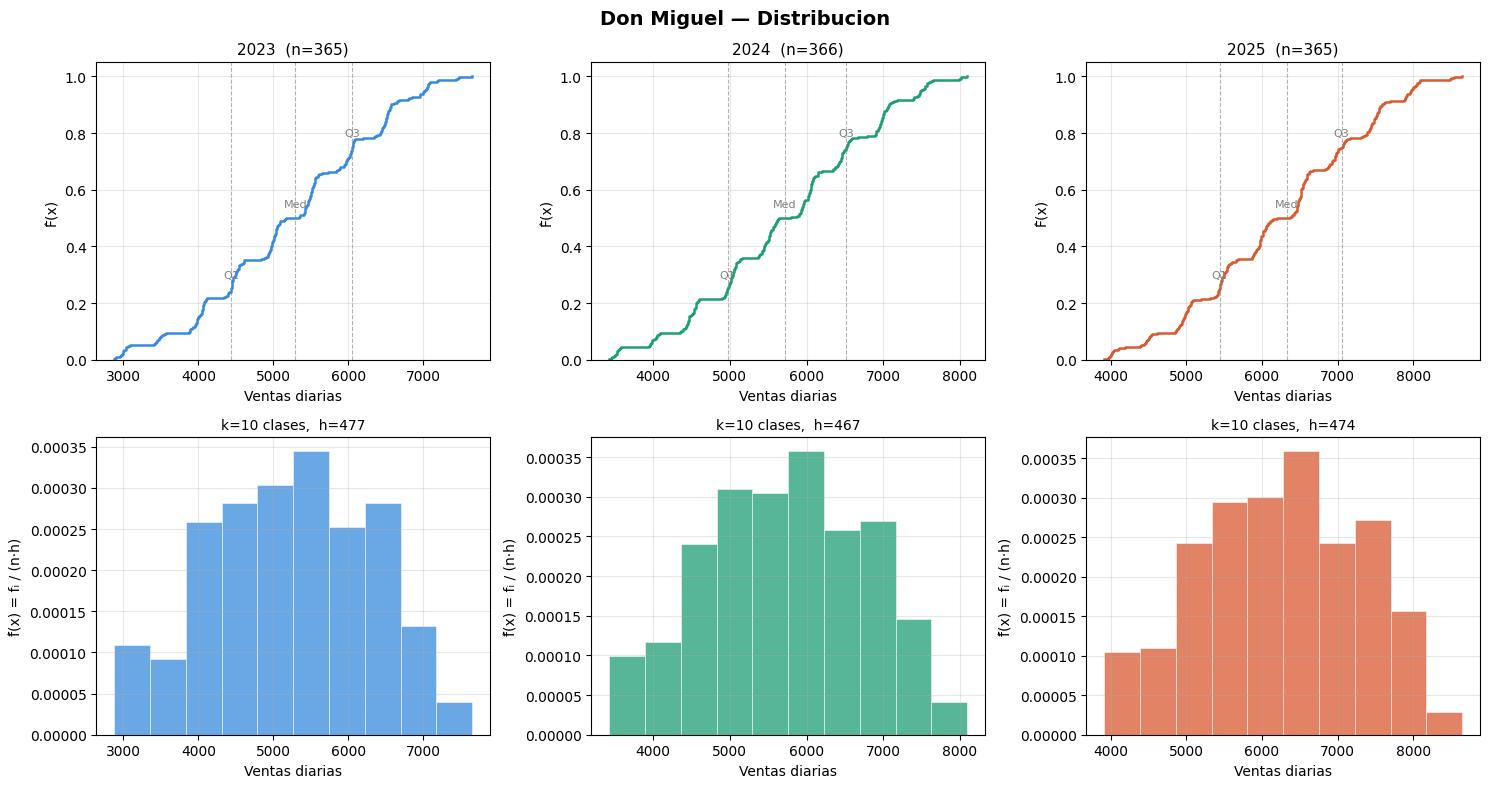


Densidad conjunta 2023: hx=467.1, hy=477.4
Verificación ∑ f̂(x,y)·hx·hy = 1.0000  (debe ser ≈ 1.0)

Densidad conjunta 2024: hx=472.1, hy=466.6
Verificación ∑ f̂(x,y)·hx·hy = 1.0000  (debe ser ≈ 1.0)

Densidad conjunta 2025: hx=469.3, hy=473.5
Verificación ∑ f̂(x,y)·hx·hy = 1.0000  (debe ser ≈ 1.0)


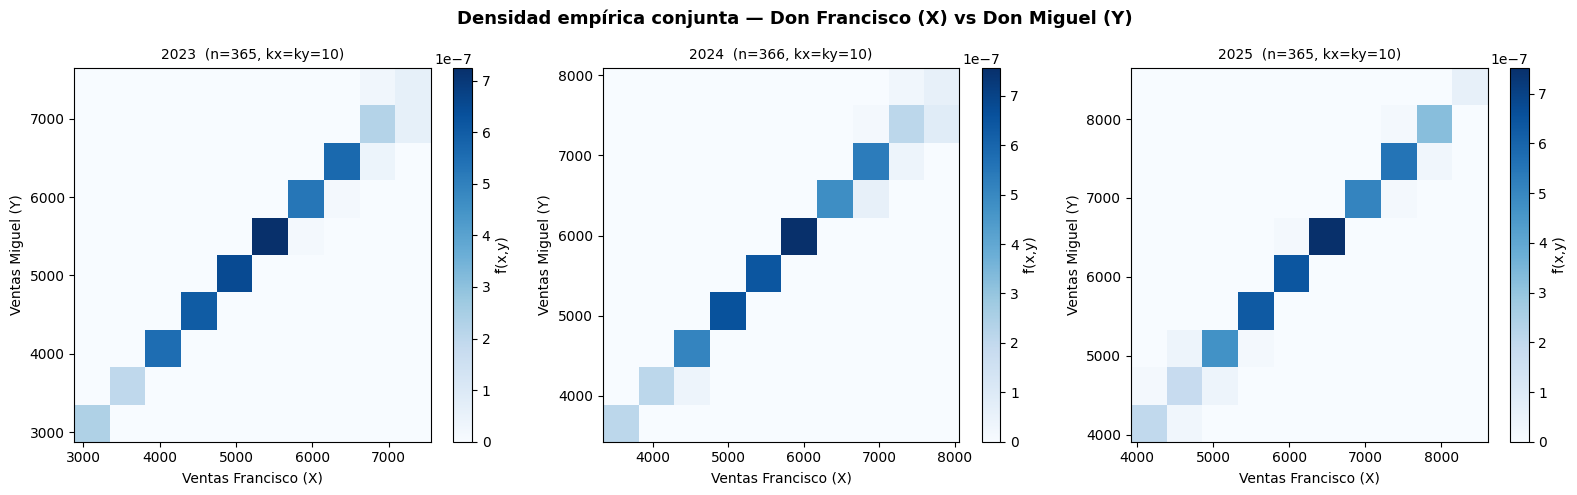

In [5]:
# incisos 2 y3
# funcion empirica y densidad 
años = [2023, 2024, 2025]
almacenes = {
    "Don Francisco": "ventas_francisco",
    "Don Miguel":    "ventas_miguel",
}

# Colores por año
colores_año = {2023: "#378ADD", 2024: "#1D9E75", 2025: "#D85A30"}

for nombre, col in almacenes.items():
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(f"{nombre} — Distribucion", fontsize=14, fontweight="bold")

    for j, año in enumerate(años):
        datos = np.sort(df[df["año"] == año][col].values)
        n = len(datos)
        color = colores_año[año]

        
        # datos ordenados con la prob asignada
        ecdf_x = datos
        ecdf_y = np.arange(1, n + 1) / n

        ax_ecdf = axes[0, j]
        ax_ecdf.step(ecdf_x, ecdf_y, where="post", color=color, linewidth=1.8)
        ax_ecdf.set_title(f"{año}  (n={n})", fontsize=11)
        ax_ecdf.set_xlabel("Ventas diarias")
        ax_ecdf.set_ylabel("F̂(x)")
        ax_ecdf.set_ylim(0, 1.05)
        ax_ecdf.grid(True, alpha=0.3)

        
        for q, label in zip([0.25, 0.50, 0.75], ["Q1", "Med", "Q3"]):
            xq = np.quantile(datos, q)
            ax_ecdf.axvline(xq, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
            ax_ecdf.text(xq, q + 0.04, label, fontsize=8, ha="center", color="gray")

        
        k = 10  # cantidad de clases
        h = (datos[-1] - datos[0]) / k  # ancho de cada clase

        # la densidad de cada barra es f_i / (n * h), asi el area total da 1
        ax_dens = axes[1, j]
        ax_dens.hist(datos, bins=k, density=True, color=color, alpha=0.75, edgecolor="white", linewidth=0.5)
        ax_dens.set_xlabel("Ventas diarias")
        ax_dens.set_ylabel("f̂(x) = fᵢ / (n·h)")
        ax_dens.set_title(f"k={k} clases,  h={h:.0f}", fontsize=10)
        ax_dens.grid(True, alpha=0.3)

        
        counts, edges = np.histogram(datos, bins=k)
        print(f"\n{nombre} {año} — k={k}, h={h:.1f}, n={n}")
        print(f"{'Intervalo':>20}  {'fᵢ':>5}  {'f̂ᵢ = fᵢ/(n·h)':>18}")
        print("-" * 50)
        for i in range(len(counts)):
            densidad = counts[i] / (n * h)
            print(f"[{edges[i]:7.0f}, {edges[i+1]:7.0f})  {counts[i]:>5}  {densidad:.8f}")
        print(f"Verificación área total: {np.sum(counts / (n * h)) * h:.4f}  (debe ser ≈ 1.0)")

    plt.tight_layout()
    plt.show()


# inciso 4
# densidad empirica conjunta
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Densidad empírica conjunta — Don Francisco (X) vs Don Miguel (Y)", fontsize=13, fontweight="bold")

for j, año in enumerate(años):
    df_año = df[df["año"] == año]
    x = df_año["ventas_francisco"].values
    y = df_año["ventas_miguel"].values
    n = len(x)

    # Misma cantidad de clases para ambos ejes
    kx = 10
    ky = 10
    hx = (x.max() - x.min()) / kx
    hy = (y.max() - y.min()) / ky

    # normalizacion
    H, xedges, yedges = np.histogram2d(x, y, bins=[kx, ky])
    densidad_conjunta = H / (n * hx * hy)

    ax = axes[j]
    im = ax.imshow(
        densidad_conjunta.T,
        origin="lower",
        aspect="auto",
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        cmap="Blues"
    )
    plt.colorbar(im, ax=ax, label="f̂(x,y)")
    ax.set_title(f"{año}  (n={n}, kx=ky={kx})", fontsize=10)
    ax.set_xlabel("Ventas Francisco (X)")
    ax.set_ylabel("Ventas Miguel (Y)")

    # tiene que sumar 1
    verificacion = np.sum(densidad_conjunta) * hx * hy
    print(f"\nDensidad conjunta {año}: hx={hx:.1f}, hy={hy:.1f}")
    print(f"Verificación ∑ f̂(x,y)·hx·hy = {verificacion:.4f}  (debe ser ≈ 1.0)")

plt.tight_layout()

plt.show()